# 🧠 Day 2 — Deep Learning & Transformer Architecture

This notebook provides a guided tour through the fundamentals of neural networks and the Transformer architecture, the core technology behind modern AI models like ChatGPT.

## 🚀 Setting Up Colab — and Turning On the GPU

Modern deep learning models benefit significantly from Graphics Processing Units (GPUs) due to their parallel processing capabilities. To leverage this, we'll ensure a T4 GPU is enabled in your Colab runtime. Neural networks perform thousands of tiny calculations, and GPUs excel at this, making training dramatically faster.

### How to enable a T4 GPU:
1.  Go to `Runtime` in the Colab menu.
2.  Select `Change runtime type`.
3.  Under `Hardware accelerator`, choose `T4 GPU`, then click `Save`.

In [1]:
import torch

# Check if a GPU is available and set the device accordingly
# 'cuda' refers to NVIDIA GPUs, which are commonly used in Colab
device = "cuda" if torch.cuda.is_available() else "cpu"

print(f"GPU available: {torch.cuda.is_available()}")
print(f"Using device: {device}")

GPU available: False
Using device: cpu


## 🟣 Session 1 — Tensors & Your First Neural Network

In this session, we'll demystify **tensors**—the fundamental data structure in deep learning—and then build and train our very first neural network to classify Iris flowers.

### 1.1 Tensors: Grids of Numbers

Everything in PyTorch (our deep-learning toolkit) is a **tensor**. A tensor is simply a container for numbers, organized by how many dimensions it has:
-   **Scalar (0-D):** A single number.
-   **Vector (1-D):** A list of numbers.
-   **Matrix (2-D):** A table or grid (rows × columns).
-   **3+D Tensor:** A cube of numbers or beyond (e.g., an image with height × width × color channels).

Understanding a tensor's `shape` is crucial, as many errors in deep learning arise from shape mismatches. It's like ensuring puzzle pieces fit together.

In [2]:
import torch

a = torch.tensor(7)                       # A scalar (0-D tensor)
b = torch.tensor([1.0, 2.0, 3.0])         # A vector (1-D tensor)
c = torch.tensor([[1.0, 2.0], [3.0, 4.0]]) # A matrix (2-D tensor)

print(f"Scalar 'a': {a} | shape: {a.shape}")
print(f"Vector 'b': {b} | shape: {b.shape}")
print(f"Matrix 'c':\n{c} | shape: {c.shape}")

# Tensors support element-wise mathematical operations
x = torch.tensor([1.0, 2.0, 3.0])
y = torch.tensor([10.0, 20.0, 30.0])
print(f"\nAddition (x + y): {x + y}")
print(f"Multiplication (x * y): {x * y}")
print(f"Sum of x: {x.sum()}")

Scalar 'a': 7 | shape: torch.Size([])
Vector 'b': tensor([1., 2., 3.]) | shape: torch.Size([3])
Matrix 'c':
tensor([[1., 2.],
        [3., 4.]]) | shape: torch.Size([2, 2])

Addition (x + y): tensor([11., 22., 33.])
Multiplication (x * y): tensor([10., 40., 90.])
Sum of x: 6.0


### 1.2 Autograd: PyTorch's Automatic Gradient Calculation

Neural networks learn by iteratively adjusting their internal **weights** to reduce prediction errors. This adjustment step, often referred to as 'walking downhill' on an error landscape, is powered by **autograd** in PyTorch. Autograd automatically computes gradients (slopes) for all operations, telling the network how each weight should be nudged to decrease the error. This means you don't need to manually calculate complex derivatives.

In [3]:
import torch

# Create a tensor 'w' for which we want to track gradients
w = torch.tensor(3.0, requires_grad=True)

# Define a simple 'error' function (e.g., w squared)
error = w ** 2

# Compute gradients backward from the error
error.backward()

print(f"Current w: {w.item()}")
print(f"Gradient (slope) at w: {w.grad.item()}")
# A positive gradient indicates that increasing 'w' would increase the error,
# so to reduce error, 'w' should move in the negative direction.

Current w: 3.0
Gradient (slope) at w: 6.0


### 1.3 Meet the Data: Iris Flowers

We'll use the classic Iris dataset for our first network. It consists of 150 flower samples, each described by 4 measurements (sepal length, sepal width, petal length, petal width) and belonging to one of 3 species. Our task is to predict the species given the 4 measurements.

We'll split the data into training and testing sets to evaluate our model's performance on unseen data, similar to best practices from Day 1.

In [4]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
import torch

# Load the Iris dataset
iris = load_iris()
X = iris.data         # Features: 150 flowers x 4 measurements
y = iris.target       # Labels: 150 species (0, 1, or 2)

print(f"Input features shape: {X.shape}")
print(f"First flower's measurements: {X[0]} -> species: {y[0]}")

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Convert data to PyTorch tensors and move to the selected device (GPU/CPU)
X_train = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train = torch.tensor(y_train, dtype=torch.long).to(device)
X_test  = torch.tensor(X_test,  dtype=torch.float32).to(device)
y_test  = torch.tensor(y_test,  dtype=torch.long).to(device)

print(f"\nTraining set prepared with {X_train.shape[0]} flowers.")

Input features shape: (150, 4)
First flower's measurements: [5.1 3.5 1.4 0.2] -> species: 0

Training set prepared with 120 flowers.


### 1.4 Build Your First Neural Network: FlowerNet

Our neural network, `FlowerNet`, will have 4 input features (the flower measurements), a 'hidden layer' of 16 neurons, and 3 output neurons (one for each species). Each neuron performs a simple 'multiply, add, and squish' operation.

-   **`nn.Linear(in_features, out_features)`**: This layer creates a linear transformation of the input data (multiplication and addition), learning weights and biases.
-   **`nn.ReLU()`**: The Rectified Linear Unit is an 'activation function' or 'squish function'. It introduces non-linearity, allowing the network to learn complex, non-linear relationships in the data. Without it, stacking layers would just be equivalent to a single linear transformation.
-   **`nn.Module`**: All PyTorch neural networks inherit from `nn.Module`. The `__init__` method defines the layers, and the `forward` method describes how data flows through these layers.

In [5]:
import torch.nn as nn

class FlowerNet(nn.Module):
    def __init__(self):
        super().__init__()
        # Layer 1: Takes 4 inputs, outputs 16 values (hidden neurons)
        self.layer1 = nn.Linear(4, 16)
        # ReLU activation function to introduce non-linearity
        self.relu = nn.ReLU()
        # Layer 2: Takes 16 inputs, outputs 3 values (one score per species)
        self.layer2 = nn.Linear(16, 3)

    def forward(self, x):
        # Data flows through layer1, then ReLU, then layer2
        x = self.layer1(x)
        x = self.relu(x)
        x = self.layer2(x)
        return x

# Create an instance of our network and move it to the specified device
model = FlowerNet().to(device)
print(model)

FlowerNet(
  (layer1): Linear(in_features=4, out_features=16, bias=True)
  (relu): ReLU()
  (layer2): Linear(in_features=16, out_features=3, bias=True)
)


### 1.5 Train FlowerNet: The Taste-Test Loop

Training is an iterative process where the network learns by repeatedly performing three steps:
1.  **Guess**: Make predictions with current weights.
2.  **Check**: Measure how wrong the predictions are using a **loss function**. For multi-class classification, `nn.CrossEntropyLoss` is commonly used.
3.  **Adjust**: Update the network's weights in the direction that reduces the loss. This is done by an **optimizer**, such as `optim.Adam`, which uses the gradients computed by autograd. The `learning rate (lr)` controls the size of these adjustment steps.

We will train the network for a certain number of **epochs**, where one epoch signifies one full pass through the entire training dataset.

In [6]:
import torch.optim as optim

# Define the loss function and the optimizer
loss_function = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01) # Learning rate of 0.01

# Train for 100 epochs
for epoch in range(100):
    # 1. Guess: Get predictions from the model for the training data
    predictions = model(X_train)

    # 2. Check: Calculate the loss (how wrong the predictions are)
    loss = loss_function(predictions, y_train)

    # 3. Adjust: Update the model's weights
    optimizer.zero_grad() # Clear previous gradients
    loss.backward()       # Compute gradients (autograd)
    optimizer.step()      # Take a step to update weights

    # Print progress every 20 epochs
    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1:3d} | Loss: {loss.item():.3f}")

Epoch  20 | Loss: 0.764
Epoch  40 | Loss: 0.483
Epoch  60 | Loss: 0.347
Epoch  80 | Loss: 0.245
Epoch 100 | Loss: 0.176


### 1.6 Grade the Network's Performance

After training, we evaluate our model on the separate test set to get an unbiased measure of its performance. During evaluation, we use `model.eval()` to turn off training-specific behaviors (like dropout, if present) and `torch.no_grad()` to disable gradient calculations, which saves memory and speeds up computation.

We use `argmax(dim=1)` to find the predicted class by selecting the output neuron with the highest score.

In [7]:
import torch

# Set the model to evaluation mode
model.eval()

# Disable gradient calculations for testing
with torch.no_grad():
    # Get predictions for the test set
    test_scores = model(X_test)
    # Get the predicted class by finding the index of the highest score
    predicted_classes = test_scores.argmax(dim=1)
    # Calculate accuracy
    accuracy = (predicted_classes == y_test).float().mean()

print(f"Test accuracy: {accuracy.item()*100:.1f}%")

Test accuracy: 100.0%


## 🟣 Session 2 — A Deeper Network That Sees Handwriting

Building on our first network, we'll now tackle a more complex task: recognizing handwritten digits. This session introduces concepts like **batching** and **dropout**, crucial for training larger, more robust neural networks.

### 2.1 Meet the Data: MNIST Handwritten Digits

FashionMNIST is a dataset of 70,000 tiny grayscale images (28x28 pixels) of 10 different clothing items (e.g., T-shirt, Trouser, Sneaker). Each pixel's value represents its darkness. Our goal is to classify these images into their correct clothing categories.

In [8]:
from torchvision import datasets, transforms
import torch

# Define transformations to convert images to PyTorch tensors
transform = transforms.ToTensor()

# Load the FashionMNIST dataset (Colab automatically downloads if not present)
train_data = datasets.FashionMNIST(root="data", train=True, download=True, transform=transform)
test_data  = datasets.FashionMNIST(root="data", train=False, download=True, transform=transform)

print(f"Total training images: {len(train_data)}")
print(f"Shape of one image: {train_data[0][0].shape} (1 channel, 28x28 pixels)")
print(f"Label of the first image: {train_data[0][1]}")

100%|██████████| 26.4M/26.4M [00:01<00:00, 18.0MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 263kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 4.99MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 22.6MB/s]

Total training images: 60000
Shape of one image: torch.Size([1, 28, 28]) (1 channel, 28x28 pixels)
Label of the first image: 9


### 2.2 Batching: Efficient Data Processing

Training a neural network on large datasets like FashionMNIST efficiently requires processing data in **batches**. Instead of feeding all 60,000 images at once (memory intensive) or one by one (slow and noisy), we process small groups (e.g., 64 images) at a time. The network updates its weights once per batch. This balances memory usage with training stability and speed.

`DataLoader` helps organize the dataset into iterable batches and can shuffle the data each epoch (`shuffle=True`) to prevent the model from memorizing the order.

In [9]:
from torch.utils.data import DataLoader

# Create DataLoaders to serve data in shuffled batches of 64
train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_data,  batch_size=64, shuffle=False)

# Peek at the shape of one batch
images, labels = next(iter(train_loader))
print(f"Shape of one batch of images: {images.shape} (64 images, 1 channel, 28x28 pixels)")
print(f"Shape of one batch of labels: {labels.shape} (64 labels)")

Shape of one batch of images: torch.Size([64, 1, 28, 28]) (64 images, 1 channel, 28x28 pixels)
Shape of one batch of labels: torch.Size([64]) (64 labels)


### 2.3 Build the Clothing Item Network — with Dropout

Our `DigitNet` (renamed from the original to align with the FashionMNIST data) will take a 28x28 pixel image, flatten it into a 784-element vector, pass it through hidden layers, and output 10 scores (one for each clothing category).

-   **`nn.Flatten()`**: Converts the 2D image (28x28) into a 1D vector (784) for input to linear layers.
-   **`nn.Dropout(p)`**: This regularization technique randomly sets a fraction `p` of neurons to zero during training. It prevents neurons from becoming too co-dependent and forces the network to learn more robust features, improving generalization to new data. Dropout is automatically disabled during evaluation.

In [10]:
import torch.nn as nn

class DigitNet(nn.Module):
    def __init__(self):
        super().__init__()
        # Flatten 28x28 image into a 784-element vector
        self.flatten = nn.Flatten()
        # First linear layer: 784 inputs -> 128 hidden neurons
        self.layer1 = nn.Linear(28 * 28, 128)
        self.relu = nn.ReLU()
        # Dropout layer: randomly ignore 20% of neurons during training
        self.dropout = nn.Dropout(0.2)
        # Second linear layer: 128 hidden neurons -> 10 outputs (one per digit/category)
        self.layer2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.flatten(x)
        x = self.relu(self.layer1(x))
        x = self.dropout(x) # Apply dropout after activation
        x = self.layer2(x)
        return x

# Create model instance and send to device
model = DigitNet().to(device)
print(model)

DigitNet(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (layer1): Linear(in_features=784, out_features=128, bias=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.2, inplace=False)
  (layer2): Linear(in_features=128, out_features=10, bias=True)
)


### 2.4 Train DigitNet: The Real-World Training Loop

The training loop for `DigitNet` follows the same `guess -> check -> adjust` pattern as `FlowerNet`, but now iterates over batches of data. Each epoch involves processing all batches, calculating the average loss, and updating weights. The learning rate (`lr`) is a critical hyperparameter; a value of `0.001` with the Adam optimizer is often a good starting point.

In [11]:
import torch.optim as optim

loss_function = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Set model to training mode (enables dropout)
model.train()

# Train for 3 epochs (full passes over the training data)
for epoch in range(3):
    running_loss = 0.0
    for images, labels in train_loader: # Iterate over batches
        # Move batch data to the selected device
        images, labels = images.to(device), labels.to(device)

        # 1. Guess: Get predictions for the current batch
        predictions = model(images)
        # 2. Check: Calculate loss
        loss = loss_function(predictions, labels)

        # 3. Adjust: Update weights
        optimizer.zero_grad() # Clear gradients
        loss.backward()       # Compute gradients
        optimizer.step()      # Update weights

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    print(f"Epoch {epoch+1} | Average Loss: {avg_loss:.3f}")

Epoch 1 | Average Loss: 0.580
Epoch 2 | Average Loss: 0.417
Epoch 3 | Average Loss: 0.377


### 2.5 Grade It and Look at Its Mistakes

We evaluate the `DigitNet` on the test set to determine its accuracy. It's also insightful to visualize individual predictions, especially those the model gets wrong. This helps in understanding the model's limitations and biases.

Test accuracy: 86.12%


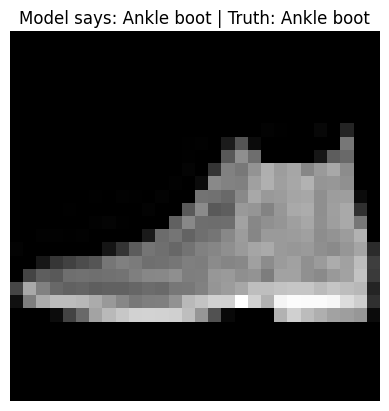

In [12]:
import torch
import matplotlib.pyplot as plt

# Set model to evaluation mode (disables dropout)
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        # Get predicted classes
        predicted = model(images).argmax(dim=1)
        # Accumulate correct predictions and total samples
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

print(f"Test accuracy: {correct/total*100:.2f}%")

# Map integer labels to readable class names for FashionMNIST
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# Grab a sample test image for visualization
img, true_label_idx = test_data[0]

with torch.no_grad():
    # Add a batch dimension (unsqueeze) and send image to device
    guess_raw = model(img.unsqueeze(0).to(device))
    guess_idx = guess_raw.argmax(dim=1).item()
    guess_name = class_names[guess_idx]

true_label_name = class_names[true_label_idx]

# Display the image and prediction
plt.imshow(img.squeeze(), cmap="gray")
plt.title(f"Model says: {guess_name} | Truth: {true_label_name}")
plt.axis("off")
plt.show()

## 🟣 Session 3 — Inside the Transformer (ChatGPT's Engine)

This session delves into the **Transformer architecture**, the revolutionary neural network design behind modern large language models (LLMs) like ChatGPT. We'll explore the core concept of **attention** and build its essential components.

### 3.1 The Problem Transformers Solve: Contextual Understanding

Traditional neural networks often process inputs as fixed-size vectors. However, language is sequential and highly contextual. The meaning of a word can change drastically based on surrounding words. For example, the word "bank" means different things in "river bank" versus "money bank."

Transformers address this by allowing every word in a sequence to 'look at' and 'pay attention to' every other word, dynamically incorporating context to understand its meaning. This mechanism is called **attention**.

### 3.2 Attention, Explained Simply

**Attention** enables a word to weigh the importance of all other words in a sentence to derive its context-aware meaning. For each word, it generates three components:

-   **Query (Q)**: What this word is *looking for* (e.g., "I am 'bank'—what context clarifies my meaning?").
-   **Key (K)**: What each word *offers* as a label or characteristic (e.g., "I am 'river', I signal nature/water").
-   **Value (V)**: The actual meaning or information each word *contributes* once it's been attended to.

The Query of a word is compared against the Keys of all words to calculate **attention scores** (relevance). These scores then determine how much of each word's Value is blended into the output representation of the current word. The result is a richer, context-aware representation for every word.

### 3.3 Build a Self-Attention Block by Hand

Let's implement a simplified self-attention mechanism in PyTorch. In **self-attention**, a word attends to other words within the *same* input sequence. The core steps involve:
1.  Generating Query, Key, and Value matrices from the input word embeddings.
2.  Computing scores by multiplying Query with the transpose of Key (`Q @ K.transpose`). This measures the similarity or relevance between words.
3.  Scaling these scores and applying a `softmax` function to turn them into attention weights (probabilities that sum to 1).
4.  Multiplying these weights with the Value matrix (`weights @ V`) to blend the contextual information into the output.

In [13]:
import torch
import torch.nn as nn

class SelfAttention(nn.Module):
    def __init__(self, embed_size):
        super().__init__()
        # Linear layers to project input into Query, Key, and Value representations
        self.query = nn.Linear(embed_size, embed_size)
        self.key   = nn.Linear(embed_size, embed_size)
        self.value = nn.Linear(embed_size, embed_size)
        # Softmax to normalize attention scores into probabilities
        self.softmax = nn.Softmax(dim=-1)

    def forward(self, x):
        # Compute Query, Key, Value for each word in the input sequence
        Q = self.query(x)
        K = self.key(x)
        V = self.value(x)

        # Calculate attention scores: Query @ Key_transpose
        # Scale by square root of embed_size for numerical stability
        scores = Q @ K.transpose(-2, -1)
        scores = scores / (x.shape[-1] ** 0.5)
        # Apply softmax to get attention weights
        weights = self.softmax(scores)

        # Multiply weights by Value to get the context-aware output
        output = weights @ V
        return output, weights

# Example: A fake sentence with 5 words, each represented by an 8-dimension embedding
fake_sentence = torch.rand(1, 5, 8) # (batch_size, sequence_length, embedding_dimension)

attn = SelfAttention(embed_size=8)
out, weights = attn(fake_sentence)

print(f"Output shape (context-aware word embeddings): {out.shape}")
print(f"Attention weights shape (who looked at whom): {weights.shape}")
# The output shape is the same as input, but each word embedding is now enriched with context.

Output shape (context-aware word embeddings): torch.Size([1, 5, 8])
Attention weights shape (who looked at whom): torch.Size([1, 5, 5])


### 3.4 The Full Encoder Block

The `SelfAttention` mechanism is just one part of a Transformer's **Encoder Block**. A full encoder block wraps attention with two additional components:

1.  **Feed-Forward Network**: A small, standard neural network (`Linear -> ReLU -> Linear`) applied independently to each word's representation after attention. It further processes the contextual information.
2.  **Residual Connections + Layer Normalization**: These are stabilization techniques:
    -   **Residual connections** (or skip connections): Add the input of a sub-layer to its output. This helps information flow through deep networks and prevents vanishing gradients, ensuring the network doesn't 'forget' the original input.
    -   **Layer Normalization**: Normalizes the activations within each layer across the embedding dimension. This keeps the numerical ranges stable, preventing training from breaking down.

In [14]:
import torch.nn as nn

class EncoderBlock(nn.Module):
    def __init__(self, embed_size):
        super().__init__()
        self.attention = SelfAttention(embed_size)
        # Layer normalization for the attention sub-layer
        self.norm1 = nn.LayerNorm(embed_size)
        # Layer normalization for the feed-forward sub-layer
        self.norm2 = nn.LayerNorm(embed_size)
        # A simple feed-forward network
        self.feed_forward = nn.Sequential(
            nn.Linear(embed_size, embed_size * 4),
            nn.ReLU(),
            nn.Linear(embed_size * 4, embed_size),
        )

    def forward(self, x):
        # 1. Apply self-attention, add residual connection, then normalize
        attn_out, _ = self.attention(x)
        x = self.norm1(x + attn_out)

        # 2. Apply feed-forward network, add residual connection, then normalize
        ff_out = self.feed_forward(x)
        x = self.norm2(x + ff_out)
        return x

block = EncoderBlock(embed_size=8)
result = block(fake_sentence)
print(f"Encoder block output shape: {result.shape}")
# This output contains richer, contextually processed word meanings.

Encoder block output shape: torch.Size([1, 5, 8])


### 3.5 Inspect a REAL Transformer: BERT

Now, let's load and inspect a famous pre-trained Transformer model: **BERT (Bidirectional Encoder Representations from Transformers)**. BERT was trained by Google on a massive amount of text and can be used for various language understanding tasks. We'll use the Hugging Face `transformers` library to easily load it.

By printing BERT's architecture, you'll observe that it consists of multiple stacked `EncoderBlock`s, remarkably similar to the one we built by hand. This demonstrates how complex models are built from foundational components.

In [15]:
from transformers import AutoTokenizer, AutoModel
import torch

# Load BERT's tokenizer and model
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
bert = AutoModel.from_pretrained("bert-base-uncased").to(device)

# Example sentence
sentence = "I sat on the river bank."

# Tokenize the sentence: convert text into numerical IDs that BERT understands
tokens = tokenizer(sentence, return_tensors="pt").to(device) # Move tokens to device

print(f"Original sentence: {sentence}")
print(f"Token IDs: {tokens['input_ids']}")
print(f"Tokens: {tokenizer.convert_ids_to_tokens(tokens['input_ids'][0])}")
# Notice special tokens like [CLS] (start) and [SEP] (separator) added by BERT.

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Original sentence: I sat on the river bank.
Token IDs: tensor([[ 101, 1045, 2938, 2006, 1996, 2314, 2924, 1012,  102]])
Tokens: ['[CLS]', 'i', 'sat', 'on', 'the', 'river', 'bank', '.', '[SEP]']


In [16]:
import torch

# Get the total number of learnable parameters in BERT
total_params = sum(p.numel() for p in bert.parameters() if p.requires_grad)
print(f"BERT has {total_params:,} learned weights.") # BERT-base has ~110 million parameters

# Print the model structure to see its layers
print("\nBERT Model Structure:")
print(bert)

# You will observe 'encoder.layer' which contains multiple EncoderBlocks,
# each with self-attention and feed-forward networks, similar to what we built.

BERT has 109,482,240 learned weights.

BERT Model Structure:
BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(30522, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (token_type_embeddings): Embedding(2, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-11): 12 x BertLayer(
        (attention): BertAttention(
          (self): BertSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=

In [17]:
import torch

# Pass the tokenized sentence through BERT
bert.eval() # Set BERT to evaluation mode
with torch.no_grad():
    output = bert(**tokens)

# The 'last_hidden_state' contains the contextualized embeddings for each token
print(f"Meaning vectors shape: {output.last_hidden_state.shape}")
# [batch_size, sequence_length, hidden_size]
# Here, [1, 7, 768] means 1 sentence, 7 tokens, each described by 768 context-aware numbers.
# These 768 numbers capture BERT's rich understanding of each token within its context.

Meaning vectors shape: torch.Size([1, 9, 768])


## 🏁 What You Built Today

Today, you journeyed from the basics of neural networks to the intricate architecture of Transformers.

-   **Tensors**: Understood as fundamental grids of numbers.
-   **Neural Networks**: Built `FlowerNet` from scratch, learned the `guess -> check -> adjust` training loop, and understood components like `ReLU`, loss functions, and optimizers.
-   **Deeper Networks**: Developed `DigitNet` for image classification, incorporating `batching` for efficiency and `dropout` for robustness.
-   **Attention**: Grasping the core concept where words dynamically consider their context.
-   **Transformer Blocks**: Implemented the `SelfAttention` mechanism and a full `EncoderBlock` by hand.
-   **BERT**: Inspected a real, pre-trained Transformer model, seeing how it scales the foundational blocks you built.

This foundational knowledge is key, as every advanced AI model—from LLMs to agentic systems—builds upon these core principles, particularly the Transformer architecture.

## ✅ Day 2 Self-Check

-   [ ] I confirmed my Colab runtime is using a GPU.
-   [ ] I can define a tensor and explain the importance of `.shape`.
-   [ ] I understand the core training loop: guess, check (loss), adjust (optimizer).
-   [ ] I built and trained a simple neural network for flower classification.
-   [ ] I can explain what `ReLU` and a 'hidden layer' do.
-   [ ] I used batching and dropout to train a deeper network for image classification.
-   [ ] I understand how attention allows words to gain context by looking at other words.
-   [ ] I built a self-attention layer and an encoder block.
-   [ ] I loaded BERT and recognized its architecture as stacked encoder blocks.

## 📚 Key Concepts Cheat-Sheet

| 🧠 Idea              | 🔑 Remember This                                                                     |
| :----------------- | :----------------------------------------------------------------------------------- |
| **Tensor**         | A grid of numbers; always check `.shape` for compatibility.                           |
| **GPU**            | Speeds up computation via parallel processing; use `.to(device)` to utilize it.      |
| **Neuron**         | Basic unit: multiplies inputs by weights, adds bias, applies activation.             |
| **Training Loop**  | Iterative process: Guess (prediction) → Check (loss) → Adjust (optimizer).           |
| **ReLU**           | Activation function: introduces non-linearity (negatives become 0, positives unchanged). |
| **Learning Rate**  | Step size for weight adjustments; crucial for effective training.                      |
| **Batch**          | A small group of examples processed together for efficient training.                   |
| **Dropout**        | Regularization: randomly ignores neurons during training to prevent overfitting.     |
| **Attention**      | Mechanism: every word weighs importance of other words for contextual meaning.        |
| **Query/Key/Value**| Roles in attention: what a word looks for / offers / contributes.                     |
| **Transformer**    | Architecture based on attention, small networks, and stabilizers (residual, layer norm). |
| **BERT**           | A large, pre-trained Transformer model for language understanding.                   |

In [18]:
# Core PyTorch Patterns and Imports

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from transformers import AutoTokenizer, AutoModel
import matplotlib.pyplot as plt

# 1. SET THE DEVICE (GPU if available, else CPU)
device = "cuda" if torch.cuda.is_available() else "cpu"

# 2. DEFINE A GENERIC NEURAL NETWORK STRUCTURE
class GenericNet(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

# 3. TRAINING LOOP ESSENTIALS (assuming model, X_train, y_train, etc. are defined)
def train_model(model, X_train, y_train, epochs, learning_rate):
    loss_fn = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    model.train() # Set model to training mode
    for epoch in range(epochs):
        predictions = model(X_train)
        loss = loss_fn(predictions, y_train)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        # print(f"Epoch {epoch+1:3d} | Loss: {loss.item():.3f}") # Uncomment for per-epoch loss

# 4. EVALUATION ESSENTIALS (assuming model, X_test, y_test are defined)
def evaluate_model(model, X_test, y_test):
    model.eval() # Set model to evaluation mode
    with torch.no_grad():
        test_scores = model(X_test)
        predicted_classes = test_scores.argmax(dim=1)
        accuracy = (predicted_classes == y_test).float().mean()
    return accuracy.item()

# 5. LOADING A PRE-TRAINED TRANSFORMER (Hugging Face)
def load_bert(sentence):
    tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
    bert_model = AutoModel.from_pretrained("bert-base-uncased").to(device)

    tokens = tokenizer(sentence, return_tensors="pt").to(device)

    bert_model.eval()
    with torch.no_grad():
        output = bert_model(**tokens)
    return output.last_hidden_state, tokenizer.convert_ids_to_tokens(tokens['input_ids'][0])

print("Core patterns and imports loaded.")


Core patterns and imports loaded.
